[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab4/lab4.ipynb)
# Práctica 4: Redes neuronales con Regularización
## El sobreajuste (overfitting)
El problema del sobreajuste (*overfitting*) consiste en que la solución aprendida se ajusta muy bien a los datos de entrenamiento, pero no generaliza adecuadamente ante la aparición de nuevos datos.

Para observar el sobreajuste en un problema, revisitaremos el problema de clasificación con datos del Titanic que hemos utilizado en los anteriores laboratorios. En primer lugar, carga los datos tal como se hacía en los anteriores notebooks. Asegúrate de tener una partición de entrenamiento con el 50\% de los datos y una de test con el 25\% y una de validación con el 25\% restante. Utiliza la función [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) de `sklearn` sobre el `ndarray` de datos en dos veces sucesivas para conseguir las particiones. Después pasa los conjuntos resultantes a `torch` y envuélvelos en un `Dataloader` como se hacía en el laboratorio anterior.

**IMPORTANTE:** La separación de conjuntos debe hacerse sobre los datos sin preprocesar. Todo preprocesado se debe hacer sobre cada conjunto por separado, pero utilizando solo información del conjunto de entrenamiento. **Revisa la carga de datos de Titanic** para que la estandarización (paso 4 de la función de carga de datos) se realice después de la partición. La función devolverá los datos sin escalar y, tras hacer la separación en train/test/val, utilizaremos un único `StandardScaler` con el que haremos `fit_transform` sobre train y `transform` sobre test y val. Así evitaremos que se filtre ningún tipo de información de test/val al entrenamiento.

In [4]:
import numpy as np
import torch
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils import data
from torch.utils.data import TensorDataset, DataLoader

# TODO - Carga el dataset Titanic en tres dataloaders: train/test/val
df = sns.load_dataset('titanic')

# --- 1. Data Cleaning and Feature Preparation ---
# Drop columns that are highly correlated, contain too many missing values, or are redundant
df_cleaned = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'])

# Fill missing 'age' values with the median of the training set (will be applied after split)
# For now, fill on the full dataset to allow splitting without NaNs causing issues,
# but conceptually this median should come from the training data only.
df_cleaned['age'] = df_cleaned['age'].fillna(df_cleaned['age'].median())

# Fill missing 'embarked' values with the mode of the training set
df_cleaned['embarked'] = df_cleaned['embarked'].fillna(df_cleaned['embarked'].mode()[0])

# Define features (X) and target (y)
X = df_cleaned.drop(columns='survived')
y = df_cleaned['survived']

# --- 2. Train/Test/Validation Split ---
# 50% for training, 50% for temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)

# Split the temporary set into 50% validation and 50% test (25% of original each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Reset indices to avoid potential issues with concatenation/indexing later
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# --- 3. Identify numerical and categorical columns ---
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# --- 4. Preprocessing: Scaling numerical features and One-Hot Encoding categorical features ---

# StandardScaler for numerical features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled = scaler.transform(X_val[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

# OneHotEncoder for categorical features (fit only on training data)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse_output=False for dense numpy array
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_val_encoded = encoder.transform(X_val[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# --- 5. Combine preprocessed features ---
X_train_processed = np.hstack((X_train_scaled, X_train_encoded))
X_val_processed = np.hstack((X_val_scaled, X_val_encoded))
X_test_processed = np.hstack((X_test_scaled, X_test_encoded))

# --- 6. Convert to PyTorch Tensors ---
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1) # unsqueeze for BCELoss

X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# --- 7. Create TensorDatasets and DataLoaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of features after preprocessing: {X_train_tensor.shape[1]}")

Train dataset size: 445
Validation dataset size: 223
Test dataset size: 223
Number of features after preprocessing: 10


Una vez hayas cargado los datos, vamos a diseñar dos funciones para entrenar y evaluar un modelo. Las funciones deben tener esta forma:
- `def measure_model(model:nn.Module, loss_fn:nn.modules.loss._Loss, data_loader:data.DataLoader) -> tuple[float, float]:`
    - Devuelve una tupla con la pérdida y la accuracy en el conjunto pasado como parámetro. Asegúrate de poner el modelo en modo `eval`.
- `def train_model(model:nn.Module,
                optimizer:optim.Optimizer,
                train_loader:data.DataLoader,
                loss_fn:nn.modules.loss._Loss,
                num_epochs:int,
                val_loader:data.DataLoader,
                patience:None|int=None) -> tuple[tuple[list[int], list[int]]:`
    - Entrena el modelo con los datos de `train_loader` y devuelve una tupla con el histórico de losses en `train_loader` y en `val_loader`. Asegúrate de poner el modelo en modo `train`.

In [11]:
def measure_model(model:nn.Module, loss_fn:nn.modules.loss._Loss, data_loader:data.DataLoader) -> tuple[float, float]:
    #TODO Completa la función
    model.eval() # Set model to evaluation mode
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # Disable gradient calculations
        for X, y in data_loader:
            outputs = model(X.float()) # Ensure input is float
            # For binary classification, targets should be float and have shape (batch_size, 1)
            loss = loss_fn(outputs, y.float()) # Removed .unsqueeze(1) as y is already (batch_size, 1)

            total_loss += loss.item() * len(y) # Sum loss weighted by batch size

            # Convert logits to probabilities and then to binary predictions
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted == y.float()).sum().item()
            total_samples += len(y)

    avg_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples
    return avg_loss, accuracy


def train_model(model:nn.Module,
                optimizer:optim.Optimizer,
                train_loader:data.DataLoader,
                loss_fn:nn.modules.loss._Loss,
                num_epochs:int,
                val_loader:data.DataLoader=None,
                patience:None|int=None) -> tuple[list[float], list[float]]:

    #TODO Completa la función
    train_losses = []
    val_losses = []

    min_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        current_train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad() # Zero the gradients

            outputs = model(X_batch.float()) # Forward pass
            loss = loss_fn(outputs, y_batch.float()) # Removed .unsqueeze(1) as y_batch is already (batch_size, 1)

            loss.backward() # Backward pass
            optimizer.step() # Update weights

            current_train_loss += loss.item() * len(y_batch)

        avg_train_loss = current_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        if val_loader is not None:
            val_loss, _ = measure_model(model, loss_fn, val_loader) # Use measure_model for validation
            val_losses.append(val_loss)

            if patience is not None:
                if val_loss < min_val_loss:
                    min_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping at epoch {epoch+1} due to no improvement in validation loss for {patience} epochs.")
                        break # Stop training

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}" +
              (f", Val Loss: {val_losses[-1]:.4f}" if val_loader is not None else ""))

    return train_losses, val_losses

Para este primer apartado, diseña una red neuronal totalmente conectada con tres capas ocultas de 20, 10 y 5 neuronas respectivamente.

In [5]:
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(20, 10)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(10, 5)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(5, 1) # Output layer for binary classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# Instantiate the model
input_features = X_train_tensor.shape[1]
model = SimpleNN(input_features)

print(model)

SimpleNN(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=20, out_features=10, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=10, out_features=5, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=5, out_features=1, bias=True)
)


Ahora entrena el modelo utilizando el optimizador `Adam` y la función de coste `BCELoss`. Tras entrenar, calcula la accuracy en test y muestra con `matplotlib` la curva de entrenamiento.

Epoch 1/700, Train Loss: 0.6821, Val Loss: 0.6820
Epoch 2/700, Train Loss: 0.6773, Val Loss: 0.6788
Epoch 3/700, Train Loss: 0.6742, Val Loss: 0.6756
Epoch 4/700, Train Loss: 0.6701, Val Loss: 0.6711
Epoch 5/700, Train Loss: 0.6636, Val Loss: 0.6644
Epoch 6/700, Train Loss: 0.6551, Val Loss: 0.6555
Epoch 7/700, Train Loss: 0.6435, Val Loss: 0.6425
Epoch 8/700, Train Loss: 0.6266, Val Loss: 0.6249
Epoch 9/700, Train Loss: 0.6051, Val Loss: 0.6023
Epoch 10/700, Train Loss: 0.5799, Val Loss: 0.5765
Epoch 11/700, Train Loss: 0.5518, Val Loss: 0.5510
Epoch 12/700, Train Loss: 0.5270, Val Loss: 0.5278
Epoch 13/700, Train Loss: 0.5037, Val Loss: 0.5089
Epoch 14/700, Train Loss: 0.4863, Val Loss: 0.4932
Epoch 15/700, Train Loss: 0.4697, Val Loss: 0.4808
Epoch 16/700, Train Loss: 0.4563, Val Loss: 0.4683
Epoch 17/700, Train Loss: 0.4445, Val Loss: 0.4592
Epoch 18/700, Train Loss: 0.4372, Val Loss: 0.4512
Epoch 19/700, Train Loss: 0.4293, Val Loss: 0.4447
Epoch 20/700, Train Loss: 0.4231, Val Lo

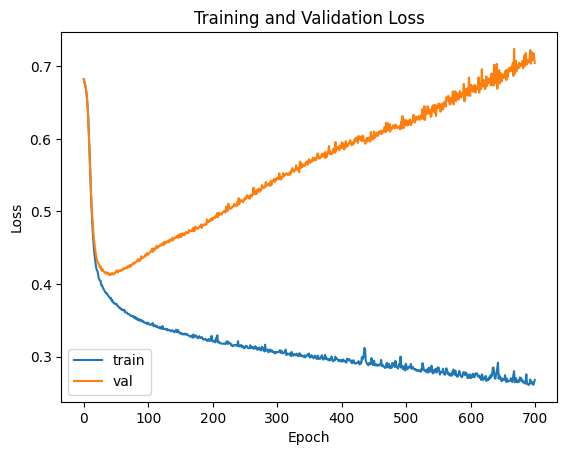

Test loss:1.0152	Test accuracy:0.80


In [12]:
import matplotlib.pyplot as pyplot

# Instantiate the model (if not already done or to re-initialize for a fresh training)
# model = SimpleNN(input_features) # Uncomment if you want to re-initialize the model

# Definimos la función de pérdida y el optimizador
loss_fn = nn.BCEWithLogitsLoss() # Use BCEWithLogitsLoss for numerical stability with sigmoid output
optimizer = optim.Adam(model.parameters(), lr=0.001) # Example learning rate

num_epochs = 700

train_losses, val_losses = train_model(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    val_loader=val_loader
)

pyplot.plot(train_losses, label="train")
pyplot.plot(val_losses, label="val")
pyplot.xlabel("Epoch")
pyplot.ylabel("Loss")
pyplot.title("Training and Validation Loss")
pyplot.legend()
pyplot.show()

test_loss, test_accuracy = measure_model(model, loss_fn, test_loader)
print(f'Test loss:{test_loss:.4f}\tTest accuracy:{test_accuracy:.2f}')

En la curva de entrenamiento deberías ser capaz de identificar que hay sobreentrenamiento porque la curva de validación llega a un punto que deja de mejorar y comienza a empeorar.

*NOTA: Puedes exagerar el efecto de sobreajuste tomando menos datos de entrenamiento, lo cual facilita su memorización.*

# Regularización
Una vez diagnosticado el sobreajuste, es hora de probar diferentes técnicas que intenten reducir la varianza, sin incrementar demasiado el sesgo y, con ello, el modelo generaliza mejor. Las técnicas de regularización que vamos a ver en este laboratorio son:
1. *Early stopping*. Detiene el entrenamiento de la red cuando aumenta el error.
1. Penalización basada	en	la	norma	de	los	parámetros (tanto norma L1 como L2).
1. *Dropout*. Ampliamente utilizada en aprendizaje profundo, "desactiva" algunas neuronas para evitar el sobreajuste.

## Parte 1. Early Stopping
Hacer parada temprana (*early stopping*) consiste en monitorizar el rendimiento en un pequeño subconjunto del conjunto de entrenamiento y parar el aprendizaje cuando este rendimiento decaiga.

Para llevarlo a cabo, añade a la función de `train_model` un parámetro opcional llamado `patience` que indique durantos cuántos pasos puede empeorar el la pérdida en validación sin que se pare el entrenamiento. Cuando esté presente el valor de `patience` el entrenamiento se tiene que parar atendiendo a él.

Una vez tengas la función, vuelve a declarar el modelo y optimizador, entrena y revisa las curvas y el rendimiento en test.

Training model with Early Stopping...
Epoch 1/700, Train Loss: 0.6613, Val Loss: 0.6664
Epoch 2/700, Train Loss: 0.6571, Val Loss: 0.6630
Epoch 3/700, Train Loss: 0.6531, Val Loss: 0.6585
Epoch 4/700, Train Loss: 0.6481, Val Loss: 0.6523
Epoch 5/700, Train Loss: 0.6408, Val Loss: 0.6435
Epoch 6/700, Train Loss: 0.6319, Val Loss: 0.6312
Epoch 7/700, Train Loss: 0.6210, Val Loss: 0.6157
Epoch 8/700, Train Loss: 0.6067, Val Loss: 0.5986
Epoch 9/700, Train Loss: 0.5926, Val Loss: 0.5800
Epoch 10/700, Train Loss: 0.5775, Val Loss: 0.5610
Epoch 11/700, Train Loss: 0.5606, Val Loss: 0.5418
Epoch 12/700, Train Loss: 0.5440, Val Loss: 0.5225
Epoch 13/700, Train Loss: 0.5260, Val Loss: 0.5034
Epoch 14/700, Train Loss: 0.5079, Val Loss: 0.4844
Epoch 15/700, Train Loss: 0.4918, Val Loss: 0.4673
Epoch 16/700, Train Loss: 0.4747, Val Loss: 0.4537
Epoch 17/700, Train Loss: 0.4607, Val Loss: 0.4430
Epoch 18/700, Train Loss: 0.4485, Val Loss: 0.4318
Epoch 19/700, Train Loss: 0.4361, Val Loss: 0.4237
Ep

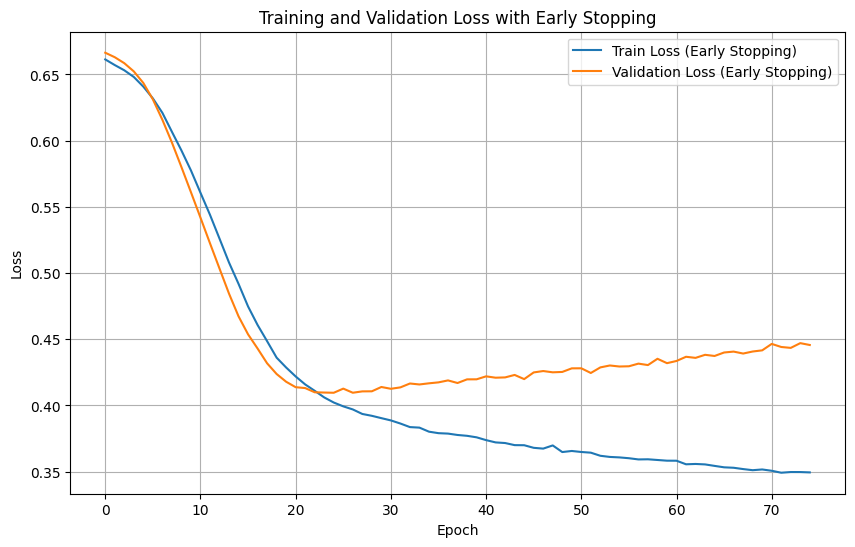

Test loss with Early Stopping: 0.4601	Test accuracy with Early Stopping: 0.82


In [13]:
# TODO - Instancia un modelo y un optimizador, haz el entrenamiento con early stopping y muestra las curvas y medidas

# Re-instantiate the model to ensure a fresh start for early stopping experiment
model_early_stopping = SimpleNN(input_features)

# Define the loss function and optimizer
loss_fn_es = nn.BCEWithLogitsLoss()
optimizer_es = optim.Adam(model_early_stopping.parameters(), lr=0.001) # Example learning rate

num_epochs_es = 700
patience_es = 50 # Example patience value

print("Training model with Early Stopping...")
train_losses_es, val_losses_es = train_model(
    model=model_early_stopping,
    optimizer=optimizer_es,
    train_loader=train_loader,
    loss_fn=loss_fn_es,
    num_epochs=num_epochs_es,
    val_loader=val_loader,
    patience=patience_es
)

# Plotting the training and validation loss curves
pyplot.figure(figsize=(10, 6))
pyplot.plot(train_losses_es, label="Train Loss (Early Stopping)")
pyplot.plot(val_losses_es, label="Validation Loss (Early Stopping)")
pyplot.xlabel("Epoch")
pyplot.ylabel("Loss")
pyplot.title("Training and Validation Loss with Early Stopping")
pyplot.legend()
pyplot.grid(True)
pyplot.show()

# Evaluate on the test set
test_loss_es, test_accuracy_es = measure_model(model_early_stopping, loss_fn_es, test_loader)
print(f'Test loss with Early Stopping: {test_loss_es:.4f}\tTest accuracy with Early Stopping: {test_accuracy_es:.2f}')

# Parte 2. Penalización basada en norma de parámetros
Otra alternativa para regularizar consiste en añadir a la función de pérdida una componente que penalice los valores altos en los parámetros. En `torch` le podemos indicar al optimizador que incluya una penalización L2 en los pesos indicando el parámetro `weight_decay` al instanciarlo. Prueba distintos valores (suele ser buena política probar cambios en factores de 10 alrededor del 0.001) y comprueba su efecto en el rendimiento. No utilices *early stopping* en el entrenamiento.

**¿Qué diferencia observas en la curva de entrenamiento con respecto a utilizar *early stopping*?**

Training model with Weight Decay (L2 regularization = 0.001)...
Epoch 1/700, Train Loss: 0.7688, Val Loss: 0.7575
Epoch 2/700, Train Loss: 0.7626, Val Loss: 0.7523
Epoch 3/700, Train Loss: 0.7574, Val Loss: 0.7477
Epoch 4/700, Train Loss: 0.7531, Val Loss: 0.7449
Epoch 5/700, Train Loss: 0.7501, Val Loss: 0.7421
Epoch 6/700, Train Loss: 0.7471, Val Loss: 0.7393
Epoch 7/700, Train Loss: 0.7440, Val Loss: 0.7362
Epoch 8/700, Train Loss: 0.7407, Val Loss: 0.7330
Epoch 9/700, Train Loss: 0.7371, Val Loss: 0.7291
Epoch 10/700, Train Loss: 0.7332, Val Loss: 0.7246
Epoch 11/700, Train Loss: 0.7285, Val Loss: 0.7196
Epoch 12/700, Train Loss: 0.7231, Val Loss: 0.7128
Epoch 13/700, Train Loss: 0.7165, Val Loss: 0.7042
Epoch 14/700, Train Loss: 0.7080, Val Loss: 0.6942
Epoch 15/700, Train Loss: 0.6984, Val Loss: 0.6838
Epoch 16/700, Train Loss: 0.6878, Val Loss: 0.6716
Epoch 17/700, Train Loss: 0.6772, Val Loss: 0.6607
Epoch 18/700, Train Loss: 0.6669, Val Loss: 0.6505
Epoch 19/700, Train Loss: 0

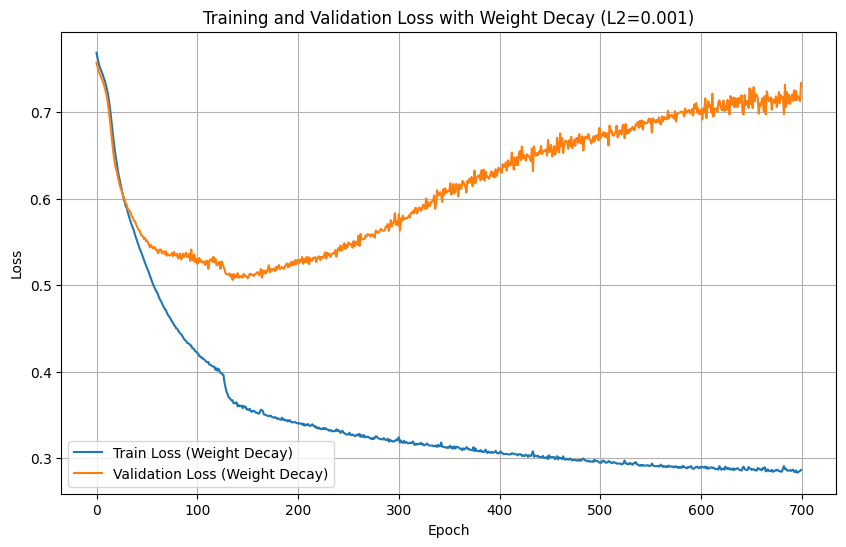

Test loss with Weight Decay: 0.9496	Test accuracy with Weight Decay: 0.78


In [14]:
# TODO - Instancia un modelo y un optimizador con weight decay, haz el entrenamiento y muestra las curvas y medidas

# Re-instantiate the model for weight decay experiment
model_weight_decay = SimpleNN(input_features)

# Define the loss function
loss_fn_wd = nn.BCEWithLogitsLoss()

# Define the optimizer with weight_decay (L2 regularization)
weight_decay_val = 0.001 # Example weight decay value
optimizer_wd = optim.Adam(model_weight_decay.parameters(), lr=0.001, weight_decay=weight_decay_val)

num_epochs_wd = 700 # Same number of epochs as original, without early stopping

print(f"Training model with Weight Decay (L2 regularization = {weight_decay_val})...")
train_losses_wd, val_losses_wd = train_model(
    model=model_weight_decay,
    optimizer=optimizer_wd,
    train_loader=train_loader,
    loss_fn=loss_fn_wd,
    num_epochs=num_epochs_wd,
    val_loader=val_loader,
    patience=None # No early stopping
)

# Plotting the training and validation loss curves
pyplot.figure(figsize=(10, 6))
pyplot.plot(train_losses_wd, label="Train Loss (Weight Decay)")
pyplot.plot(val_losses_wd, label="Validation Loss (Weight Decay)")
pyplot.xlabel("Epoch")
pyplot.ylabel("Loss")
pyplot.title(f"Training and Validation Loss with Weight Decay (L2={weight_decay_val})")
pyplot.legend()
pyplot.grid(True)
pyplot.show()

# Evaluate on the test set
test_loss_wd, test_accuracy_wd = measure_model(model_weight_decay, loss_fn_wd, test_loader)
print(f'Test loss with Weight Decay: {test_loss_wd:.4f}\tTest accuracy with Weight Decay: {test_accuracy_wd:.2f}')

# Parte 3. Dropout
Por último, la tercera alternativa que exploraremos para regularizar es añadir capas `nn.Dropout` a nuestra arquitectura. Estas capas apagan durante el entrenamiento una fracción (que debemos indicar como parámetro al instanciar la capa) de las neuronas que reciben a la entrada, impidiendo al modelo apoyarse siempre en las mismas entradas para hacer sus predicciones, forzándolo así a aprender representaciones más generales y, por tanto, mejorando su generalización.

Crea una nueva arquitectura de red con estas capas y entrénala (sin usar ningún otro mecanismo de regularización). Prueba a situar las capas `nn.Dropout` en distintos sitios y a aplicar distintos valores del parámetro `p` que indica la probabilidad de que se apague cada neurona.

Training model with Dropout (p=0.5)...
Epoch 1/700, Train Loss: 0.6787, Val Loss: 0.6791
Epoch 2/700, Train Loss: 0.6738, Val Loss: 0.6748
Epoch 3/700, Train Loss: 0.6711, Val Loss: 0.6706
Epoch 4/700, Train Loss: 0.6659, Val Loss: 0.6658
Epoch 5/700, Train Loss: 0.6618, Val Loss: 0.6601
Epoch 6/700, Train Loss: 0.6469, Val Loss: 0.6532
Epoch 7/700, Train Loss: 0.6452, Val Loss: 0.6459
Epoch 8/700, Train Loss: 0.6397, Val Loss: 0.6376
Epoch 9/700, Train Loss: 0.6333, Val Loss: 0.6286
Epoch 10/700, Train Loss: 0.6257, Val Loss: 0.6195
Epoch 11/700, Train Loss: 0.6177, Val Loss: 0.6108
Epoch 12/700, Train Loss: 0.6027, Val Loss: 0.6015
Epoch 13/700, Train Loss: 0.6149, Val Loss: 0.5922
Epoch 14/700, Train Loss: 0.5906, Val Loss: 0.5852
Epoch 15/700, Train Loss: 0.6109, Val Loss: 0.5801
Epoch 16/700, Train Loss: 0.5912, Val Loss: 0.5743
Epoch 17/700, Train Loss: 0.5943, Val Loss: 0.5679
Epoch 18/700, Train Loss: 0.5921, Val Loss: 0.5625
Epoch 19/700, Train Loss: 0.5813, Val Loss: 0.5574
E

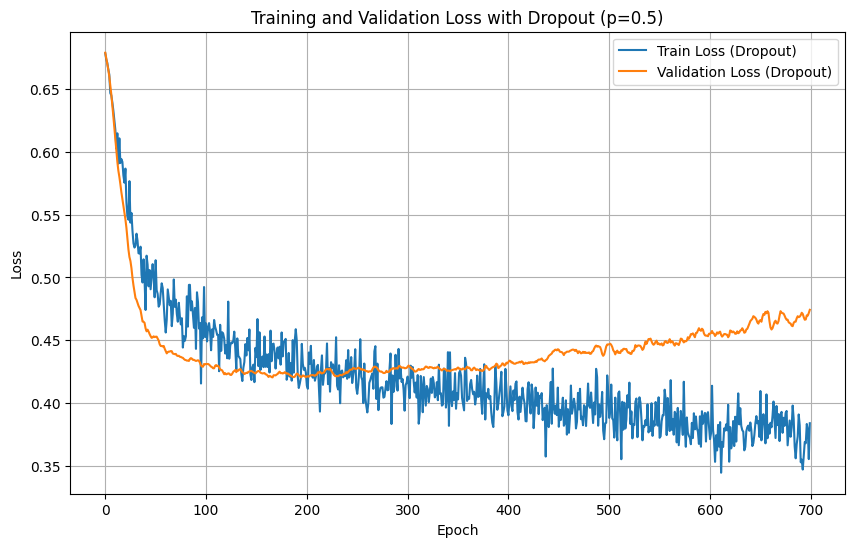

Test loss with Dropout: 0.5449	Test accuracy with Dropout: 0.80


In [15]:

# TODO - Declara la nueva clase, haz que tu modelo sea una instancia de ella, instancia el optimizador, haz el entrenamiento y muestra las curvas y medidas.

class SimpleNNWithDropout(nn.Module):
    def __init__(self, input_size, dropout_prob=0.5):
        super(SimpleNNWithDropout, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_prob) # Dropout after first ReLU

        self.fc2 = nn.Linear(20, 10)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_prob) # Dropout after second ReLU

        self.fc3 = nn.Linear(10, 5)
        self.relu3 = nn.ReLU()
        # No dropout after the last hidden layer typically, or just before the output layer
        self.fc4 = nn.Linear(5, 1) # Output layer for binary classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# Instantiate the model with dropout
dropout_probability = 0.5 # Example dropout probability
model_dropout = SimpleNNWithDropout(input_features, dropout_prob=dropout_probability)

# Define the loss function
loss_fn_do = nn.BCEWithLogitsLoss()

# Define the optimizer
optimizer_do = optim.Adam(model_dropout.parameters(), lr=0.001)

num_epochs_do = 700 # Same number of epochs, no early stopping, no weight decay

print(f"Training model with Dropout (p={dropout_probability})...")
train_losses_do, val_losses_do = train_model(
    model=model_dropout,
    optimizer=optimizer_do,
    train_loader=train_loader,
    loss_fn=loss_fn_do,
    num_epochs=num_epochs_do,
    val_loader=val_loader,
    patience=None # No early stopping
)

# Plotting the training and validation loss curves
pyplot.figure(figsize=(10, 6))
pyplot.plot(train_losses_do, label="Train Loss (Dropout)")
pyplot.plot(val_losses_do, label="Validation Loss (Dropout)")
pyplot.xlabel("Epoch")
pyplot.ylabel("Loss")
pyplot.title(f"Training and Validation Loss with Dropout (p={dropout_probability})")
pyplot.legend()
pyplot.grid(True)
pyplot.show()

# Evaluate on the test set
test_loss_do, test_accuracy_do = measure_model(model_dropout, loss_fn_do, test_loader)
print(f'Test loss with Dropout: {test_loss_do:.4f}\tTest accuracy with Dropout: {test_accuracy_do:.2f}')